# GRASSY-DiT Generation Evaluation

This notebook evaluates:
1. Random (unconditioned) generation
2. Conditioned generation on scattering moments
3. RDKit validity and quality scores
4. Scattering moment matching (conditioned vs random)


In [4]:
import torch
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, QED
from rdkit.Chem import rdMolDescriptors
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path (notebook is in grassy_dit/, need to import from root)
notebook_dir = Path().resolve()
if notebook_dir.name == 'grassy_dit':
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir
sys.path.insert(0, str(project_root))

# Change to project root for consistent path handling
os.chdir(project_root)

from grassy_dit.train import ScatteringGraphDIT
from models.LEGS_module import Scatter
from datasets.load_ZINC_tranche import ZINCDataset, mol_to_pyg
from torch_geometric.loader import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Project root: {project_root}")
print(f"Current directory: {os.getcwd()}")


Using device: cpu
Project root: /mnt/c/Users/stolk/OneDrive/github/GRASSY-Net
Current directory: /mnt/c/Users/stolk/OneDrive/github/GRASSY-Net


In [8]:
# Load scattering moments first to determine num_atom_types
scattering_moments = np.load('grassy_dit/data/scattering_moments.npy')
scattering_dim = scattering_moments.shape[1]
num_levels = 11
num_moments = 4
num_atom_types = scattering_dim // (num_levels * num_moments)

print(f"Scattering dimension: {scattering_dim}")
print(f"Computed num_atom_types: {num_atom_types}")

# Check what the most recent checkpoint expects
import torch
checkpoint_path = 'grassy_dit_checkpoint.pt'  # Most recent (Jan 6, root directory)
ckpt = torch.load(checkpoint_path, map_location='cpu')
pos_shape = ckpt['model_state_dict']['denoiser.scatter_tokenizer.pos'].shape
checkpoint_num_tokens = pos_shape[1]
checkpoint_num_atom_types = checkpoint_num_tokens - 11  # Subtract 11 levels
print(f"\nCheckpoint expects: {checkpoint_num_atom_types} atom types")
print(f"Checkpoint expected scattering_dim: {checkpoint_num_atom_types * 11 * 4}")

# Use the checkpoint's num_atom_types (must match what it was trained with)
model = ScatteringGraphDIT()
model.num_atom_types = checkpoint_num_atom_types  # Use checkpoint's value, not computed
model.num_levels = num_levels
model.num_moments = num_moments

# Now load the checkpoint
model.load_from_local(checkpoint_path)
print("Model loaded successfully")

Scattering dimension: 704
Computed num_atom_types: 16

Checkpoint expects: 16 atom types
Checkpoint expected scattering_dim: 704
Model successfully loaded from local path: grassy_dit_checkpoint.pt
Model loaded successfully


In [9]:
# Load scattering model for extracting moments from generated molecules
dataset = ZINCDataset('datasets/ZINC12K.npy', prop_stat_dict='datasets/ZINC12K_stats.npy', include_ki=False)
scatter = Scatter(in_channels=dataset.num_node_features, trainable_laziness=False).to(device)
scatter.load_state_dict(torch.load('scripts/trained_models/ZINC12K.npy', map_location=device))
scatter.eval()
print("Scattering model loaded")


Scattering model loaded


In [10]:
# Load target scattering moments from dataset
scattering_moments = np.load('grassy_dit/data/scattering_moments.npy')
print(f"Loaded {len(scattering_moments)} scattering moments")
print(f"Scattering dimension: {scattering_moments.shape[1]}")

# Select a few target scattering moments for conditioning
target_indices = [0, 100, 500, 1000, 2000]
target_scatterings = scattering_moments[target_indices]
print(f"Selected {len(target_scatterings)} target scattering moments")


Loaded 11994 scattering moments
Scattering dimension: 704
Selected 5 target scattering moments


In [11]:
def compute_rdkit_scores(smiles):
    """Compute RDKit validity and quality scores for a SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return {
            'valid': False,
            'qed': None,
            'sa_score': None,
            'num_atoms': None,
            'num_rings': None
        }
    
    try:
        qed = QED.qed(mol)
    except:
        qed = None
    
    try:
        sa_score = rdMolDescriptors.CalcSAScore(mol)
    except:
        sa_score = None
    
    try:
        num_rings = mol.GetRingInfo().NumRings()
    except:
        num_rings = None
    
    return {
        'valid': True,
        'qed': qed,
        'sa_score': sa_score,
        'num_atoms': mol.GetNumAtoms(),
        'num_rings': num_rings
    }


In [12]:
def extract_scattering_from_smiles(smiles, scatter_model, device):
    """Extract scattering moments from a SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    # Convert to PyG format
    data = mol_to_pyg(mol)
    
    # Create node features with the same encoding as ZINCDataset
    num_node_features = 16  # 8 atom types + 8 pairs
    node_feat = torch.zeros(data.num_nodes, num_node_features)
    
    # One-hot encoding of atoms (8 types: C, O, N, S, F, Cl, Br, I)
    atom_type_map = {'C': 0, 'O': 1, 'N': 2, 'S': 3, 'F': 4, 'Cl': 5, 'Br': 6, 'I': 7}
    
    for i, atom in enumerate(mol.GetAtoms()):
        entry = atom.GetSymbol()
        if entry in atom_type_map:
            node_feat[i, atom_type_map[entry]] = 1.0
        
        # Pair encoding (8 pairs: C-O, C-N, C-S, N-O, O-S, N-S, C-F, C-Cl)
        neighbors = [mol.GetAtomWithIdx(nbr.GetIdx()).GetSymbol() for nbr in atom.GetNeighbors()]
        for nbr_symbol in neighbors:
            if entry == 'C' and nbr_symbol == 'O':
                node_feat[i, 8] = 1.0  # C-O pair
            if entry == 'C' and nbr_symbol == 'N':
                node_feat[i, 9] = 1.0  # C-N pair
            if entry == 'C' and nbr_symbol == 'S':
                node_feat[i, 10] = 1.0  # C-S pair
            if (entry == 'O' and nbr_symbol == 'N') or (entry == 'N' and nbr_symbol == 'O'):
                node_feat[i, 11] = 1.0  # N-O pair
            if (entry == 'O' and nbr_symbol == 'S') or (entry == 'S' and nbr_symbol == 'O'):
                node_feat[i, 12] = 1.0  # O-S pair
            if (entry == 'N' and nbr_symbol == 'S') or (entry == 'S' and nbr_symbol == 'N'):
                node_feat[i, 13] = 1.0  # N-S pair
            if entry == 'C' and nbr_symbol == 'F':
                node_feat[i, 14] = 1.0  # C-F pair
            if entry == 'C' and nbr_symbol == 'Cl':
                node_feat[i, 15] = 1.0  # C-Cl pair
    
    data.x = node_feat
    
    # Convert edge weights to edge_attr format expected by Scatter
    edge_attr = []
    for bond in mol.GetBonds():
        bt = bond.GetBondType()
        if bt == Chem.BondType.SINGLE:
            edge_attr.append(1)
        elif bt == Chem.BondType.DOUBLE:
            edge_attr.append(2)
        elif bt == Chem.BondType.TRIPLE:
            edge_attr.append(3)
        elif bt == Chem.BondType.AROMATIC:
            edge_attr.append(3)  # Aromatic mapped to 3
        else:
            edge_attr.append(1)  # Default to single
    
    # Duplicate for bidirectional edges
    edge_attr_full = []
    for i in range(len(edge_attr)):
        edge_attr_full.extend([edge_attr[i], edge_attr[i]])
    
    data.edge_attr = torch.tensor(edge_attr_full, dtype=torch.long)
    
    # Move to device and extract scattering
    data = data.to(device)
    
    with torch.no_grad():
        moments, _ = scatter_model(data)
    
    return moments.cpu().numpy().flatten()


In [14]:
# Generate random (unconditioned) molecules
print("Generating random molecules...")
num_samples = 5

# For unconditional generation, we can pass zeros or None for scattering
# Let's try passing zeros (null conditioning)
null_scattering = np.zeros((num_samples, scattering_moments.shape[1]))

random_smiles = model.generate(
    scattering=null_scattering,
    num_nodes=None,  # Sample from training distribution
    batch_size=num_samples
)

print(f"Generated {len(random_smiles)} random molecules")
print(f"Valid SMILES: {sum(1 for s in random_smiles if s is not None)}")


Generating random molecules...
Generated 5 random molecules
Valid SMILES: 3


In [16]:
# Generate conditioned molecules
print("Generating conditioned molecules...")
conditioned_smiles_list = []
target_scatterings_list = []

for i, target_scat in enumerate(target_scatterings):
    print(f"Generating for target {i+1}/{len(target_scatterings)}...")
    
    # Generate multiple samples per target
    samples_per_target = 2
    conditioned_smiles = model.generate(
        scattering=target_scat,
        num_nodes=None,
        batch_size=samples_per_target
    )
    
    conditioned_smiles_list.extend(conditioned_smiles)
    target_scatterings_list.extend([target_scat] * samples_per_target)

print(f"Generated {len(conditioned_smiles_list)} conditioned molecules")


Generating conditioned molecules...
Generating for target 1/5...
Generating for target 2/5...
Generating for target 3/5...
Generating for target 4/5...
Generating for target 5/5...
Generated 10 conditioned molecules


In [17]:
# Evaluate RDKit scores for random molecules
print("Evaluating random molecules...")
random_scores = []
for smi in random_smiles:
    if smi is not None:
        scores = compute_rdkit_scores(smi)
        scores['smiles'] = smi
        scores['type'] = 'random'
        random_scores.append(scores)

random_df = pd.DataFrame(random_scores)
print(f"\nRandom molecules:")
print(f"  Valid: {random_df['valid'].sum()}/{len(random_df)}")
print(f"  Mean QED: {random_df['qed'].mean():.3f}")
print(f"  Mean SA Score: {random_df['sa_score'].mean():.3f}")


Evaluating random molecules...

Random molecules:
  Valid: 0/3
  Mean QED: nan
  Mean SA Score: nan


In [18]:
# Evaluate RDKit scores for conditioned molecules
print("Evaluating conditioned molecules...")
conditioned_scores = []
for smi in conditioned_smiles_list:
    if smi is not None:
        scores = compute_rdkit_scores(smi)
        scores['smiles'] = smi
        scores['type'] = 'conditioned'
        conditioned_scores.append(scores)

conditioned_df = pd.DataFrame(conditioned_scores)
print(f"\nConditioned molecules:")
print(f"  Valid: {conditioned_df['valid'].sum()}/{len(conditioned_df)}")
print(f"  Mean QED: {conditioned_df['qed'].mean():.3f}")
print(f"  Mean SA Score: {conditioned_df['sa_score'].mean():.3f}")


Evaluating conditioned molecules...

Conditioned molecules:
  Valid: 0/9
  Mean QED: nan
  Mean SA Score: nan


In [19]:
# Extract scattering moments from generated molecules
print("Extracting scattering moments from random molecules...")
random_scatterings = []
for smi in random_smiles:
    if smi is not None:
        scat = extract_scattering_from_smiles(smi, scatter, device)
        if scat is not None:
            random_scatterings.append(scat)

print(f"Extracted {len(random_scatterings)} scattering moments from random molecules")


Extracting scattering moments from random molecules...
Extracted 0 scattering moments from random molecules


In [20]:
# Extract scattering moments from conditioned molecules
print("Extracting scattering moments from conditioned molecules...")
conditioned_scatterings = []
for smi in conditioned_smiles_list:
    if smi is not None:
        scat = extract_scattering_from_smiles(smi, scatter, device)
        if scat is not None:
            conditioned_scatterings.append(scat)

print(f"Extracted {len(conditioned_scatterings)} scattering moments from conditioned molecules")


Extracting scattering moments from conditioned molecules...
Extracted 0 scattering moments from conditioned molecules


In [21]:
# Compute scattering moment distances
# For conditioned: compare to target scattering
# For random: compare to a random target (or average)

def compute_scattering_distance(scat1, scat2):
    """Compute L2 distance between scattering moments."""
    return np.linalg.norm(scat1 - scat2)

# Conditioned molecules: compare to their target
conditioned_distances = []
for i, (smi, target_scat) in enumerate(zip(conditioned_smiles_list, target_scatterings_list)):
    if smi is not None:
        gen_scat = extract_scattering_from_smiles(smi, scatter, device)
        if gen_scat is not None:
            dist = compute_scattering_distance(gen_scat, target_scat)
            conditioned_distances.append(dist)

# Random molecules: compare to random targets from dataset
random_targets = scattering_moments[np.random.choice(len(scattering_moments), len(random_scatterings))]
random_distances = []
for gen_scat, target_scat in zip(random_scatterings, random_targets):
    dist = compute_scattering_distance(gen_scat, target_scat)
    random_distances.append(dist)

print(f"\nScattering moment distances:")
print(f"  Conditioned (mean): {np.mean(conditioned_distances):.3f}")
print(f"  Random (mean): {np.mean(random_distances):.3f}")
print(f"  Improvement: {(np.mean(random_distances) - np.mean(conditioned_distances)) / np.mean(random_distances) * 100:.1f}% closer")



Scattering moment distances:
  Conditioned (mean): nan
  Random (mean): nan
  Improvement: nan% closer


/home/stolk/miniconda3/envs/grassy_dit/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/stolk/miniconda3/envs/grassy_dit/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


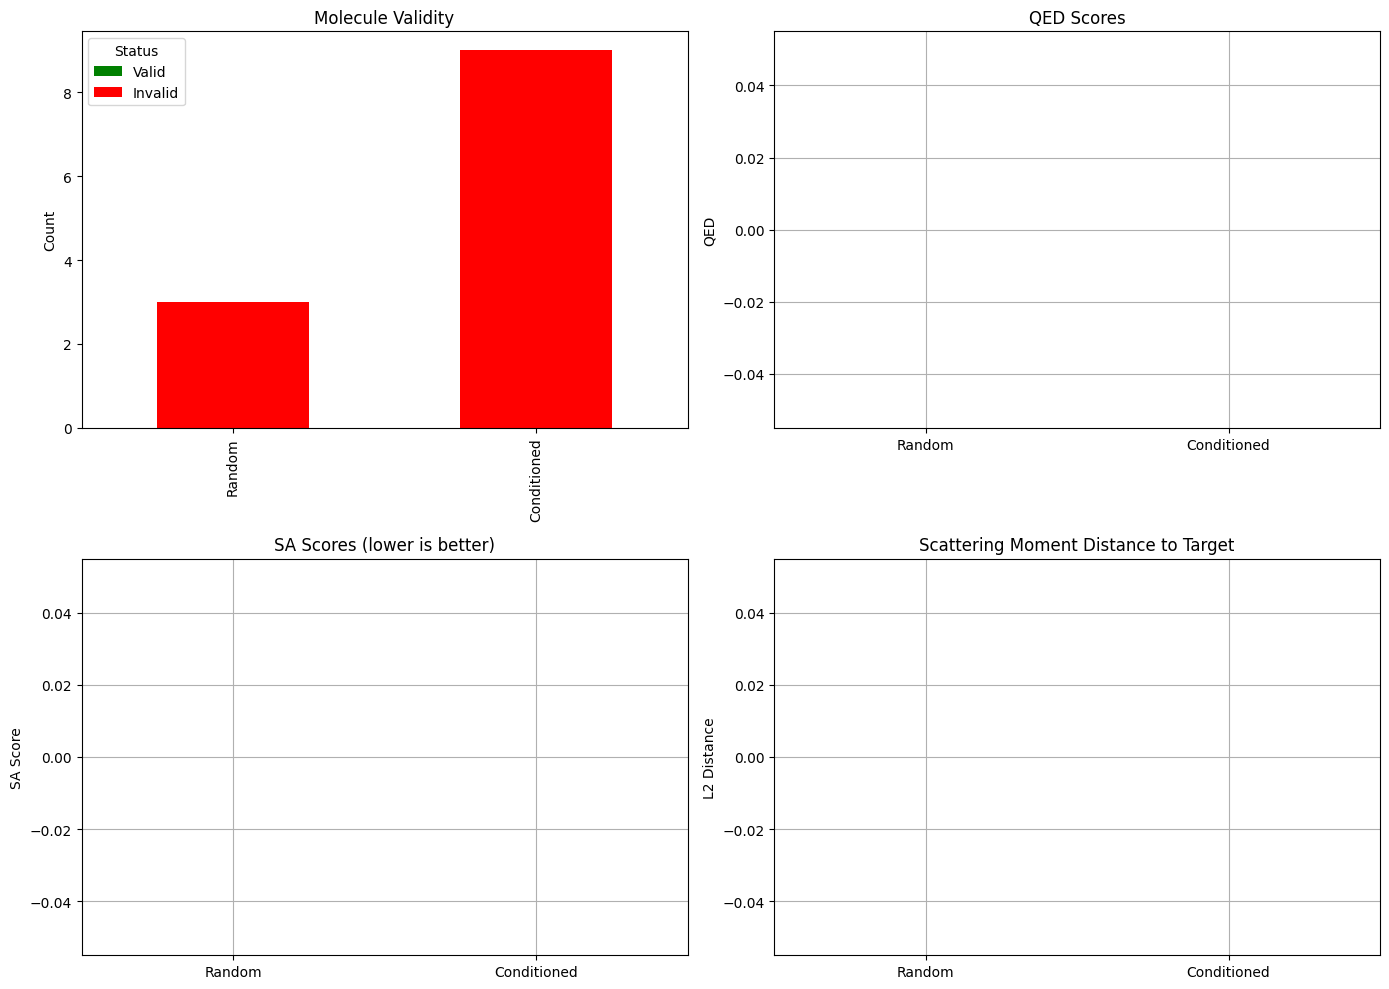

In [22]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Validity comparison
ax = axes[0, 0]
validity_data = {
    'Random': [random_df['valid'].sum(), len(random_df) - random_df['valid'].sum()],
    'Conditioned': [conditioned_df['valid'].sum(), len(conditioned_df) - conditioned_df['valid'].sum()]
}
df_valid = pd.DataFrame(validity_data, index=['Valid', 'Invalid']).T
df_valid.plot(kind='bar', stacked=True, ax=ax, color=['green', 'red'])
ax.set_title('Molecule Validity')
ax.set_ylabel('Count')
ax.legend(title='Status')

# 2. QED comparison
ax = axes[0, 1]
qed_data = pd.DataFrame({
    'Random': random_df['qed'].dropna().tolist(),
    'Conditioned': conditioned_df['qed'].dropna().tolist()
})
qed_data.boxplot(ax=ax)
ax.set_title('QED Scores')
ax.set_ylabel('QED')

# 3. SA Score comparison
ax = axes[1, 0]
sa_data = pd.DataFrame({
    'Random': random_df['sa_score'].dropna().tolist(),
    'Conditioned': conditioned_df['sa_score'].dropna().tolist()
})
sa_data.boxplot(ax=ax)
ax.set_title('SA Scores (lower is better)')
ax.set_ylabel('SA Score')

# 4. Scattering distance comparison
ax = axes[1, 1]
dist_data = pd.DataFrame({
    'Random': random_distances,
    'Conditioned': conditioned_distances
})
dist_data.boxplot(ax=ax)
ax.set_title('Scattering Moment Distance to Target')
ax.set_ylabel('L2 Distance')

plt.tight_layout()
plt.savefig('grassy_dit/generation_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


In [23]:
# Summary statistics
print("=" * 60)
print("GENERATION EVALUATION SUMMARY")
print("=" * 60)

print("\n1. VALIDITY:")
print(f"   Random: {random_df['valid'].sum()}/{len(random_df)} ({random_df['valid'].mean()*100:.1f}%)")
print(f"   Conditioned: {conditioned_df['valid'].sum()}/{len(conditioned_df)} ({conditioned_df['valid'].mean()*100:.1f}%)")

print("\n2. QUALITY SCORES:")
print(f"   Random QED: {random_df['qed'].mean():.3f} ± {random_df['qed'].std():.3f}")
print(f"   Conditioned QED: {conditioned_df['qed'].mean():.3f} ± {conditioned_df['qed'].std():.3f}")
print(f"   Random SA: {random_df['sa_score'].mean():.3f} ± {random_df['sa_score'].std():.3f}")
print(f"   Conditioned SA: {conditioned_df['sa_score'].mean():.3f} ± {conditioned_df['sa_score'].std():.3f}")

print("\n3. SCATTERING MOMENT MATCHING:")
print(f"   Random distance: {np.mean(random_distances):.3f} ± {np.std(random_distances):.3f}")
print(f"   Conditioned distance: {np.mean(conditioned_distances):.3f} ± {np.std(conditioned_distances):.3f}")
improvement = (np.mean(random_distances) - np.mean(conditioned_distances)) / np.mean(random_distances) * 100
print(f"   Conditioned molecules are {improvement:.1f}% closer to target scattering moments")

print("\n4. SAMPLE MOLECULES:")
print("\n   Random samples:")
for i, smi in enumerate(random_smiles[:3]):
    if smi is not None:
        print(f"     {i+1}. {smi}")

print("\n   Conditioned samples:")
for i, smi in enumerate(conditioned_smiles_list[:3]):
    if smi is not None:
        print(f"     {i+1}. {smi}")


GENERATION EVALUATION SUMMARY

1. VALIDITY:
   Random: 0/3 (0.0%)
   Conditioned: 0/9 (0.0%)

2. QUALITY SCORES:
   Random QED: nan ± nan
   Conditioned QED: nan ± nan
   Random SA: nan ± nan
   Conditioned SA: nan ± nan

3. SCATTERING MOMENT MATCHING:
   Random distance: nan ± nan
   Conditioned distance: nan ± nan
   Conditioned molecules are nan% closer to target scattering moments

4. SAMPLE MOLECULES:

   Random samples:
     1. O.O=[N+]1CC23c4c5c-c26c2c5[N+]57C3C3(I)CFC5C4(C1)c71c45cS(=O)(=C36c3(cn3)n4)c25C1
     3. C.COCc12n3cn3cn3coc1(Cl)CCCC2NO3

   Conditioned samples:
     1. C.O.ccc1cc2(C)c3c-2CC=C3(NO)([SH](=O)=O)Occ[O+]1C
     2. C.COc1ccc2c34cc56c78c29-c(o)c2C1%10NCC37CC5(O=S1(=CO1)c6-2%10-9)N(C)(C)(C4)C8
     3. C.CC1C2(C)=C3=C45CC(C34C)C34NC15678(CC6)sc7c31(=O)=C8[SH]=14C2


/home/stolk/miniconda3/envs/grassy_dit/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/stolk/miniconda3/envs/grassy_dit/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/stolk/miniconda3/envs/grassy_dit/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/stolk/miniconda3/envs/grassy_dit/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/stolk/miniconda3/envs/grassy_dit/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [24]:
# Evaluate RDKit scores for random molecules
print("Evaluating random molecules...")
print("\nGenerated SMILES:")
for i, smi in enumerate(random_smiles):
    print(f"  {i+1}. {repr(smi)}")  # repr() shows None, empty strings, etc.

random_scores = []
for smi in random_smiles:
    if smi is not None:
        print(f"\nTrying to parse: {repr(smi)}")
        scores = compute_rdkit_scores(smi)
        scores['smiles'] = smi
        scores['type'] = 'random'
        random_scores.append(scores)
        print(f"  Valid: {scores['valid']}")

random_df = pd.DataFrame(random_scores)
print(f"\nRandom molecules:")
print(f"  Valid: {random_df['valid'].sum()}/{len(random_df)}")
print(f"  Mean QED: {random_df['qed'].mean():.3f}")
print(f"  Mean SA Score: {random_df['sa_score'].mean():.3f}")

Evaluating random molecules...

Generated SMILES:
  1. 'O.O=[N+]1CC23c4c5c-c26c2c5[N+]57C3C3(I)CFC5C4(C1)c71c45cS(=O)(=C36c3(cn3)n4)c25C1'
  2. None
  3. 'C.COCc12n3cn3cn3coc1(Cl)CCCC2NO3'
  4. None
  5. 'CSNCO.ccc(OCF)-c1c23ccn(C)c24n12c1c(n12C4)C=[N+]1NC13'

Trying to parse: 'O.O=[N+]1CC23c4c5c-c26c2c5[N+]57C3C3(I)CFC5C4(C1)c71c45cS(=O)(=C36c3(cn3)n4)c25C1'
  Valid: False

Trying to parse: 'C.COCc12n3cn3cn3coc1(Cl)CCCC2NO3'
  Valid: False

Trying to parse: 'CSNCO.ccc(OCF)-c1c23ccn(C)c24n12c1c(n12C4)C=[N+]1NC13'
  Valid: False

Random molecules:
  Valid: 0/3
  Mean QED: nan
  Mean SA Score: nan


In [25]:
# Generate random (unconditioned) molecules
print("Generating random molecules...")
num_samples = 5

null_scattering = np.zeros((num_samples, scattering_moments.shape[1]))

random_smiles = model.generate(
    scattering=null_scattering,
    num_nodes=None,
    batch_size=num_samples
)

print(f"Generated {len(random_smiles)} items")
print("\nWhat was actually returned:")
for i, item in enumerate(random_smiles):
    print(f"  {i+1}. Type: {type(item)}, Value: {repr(item)}")
    if isinstance(item, str):
        print(f"      Length: {len(item)}, Is empty: {item == ''}")
    elif item is None:
        print(f"      This is None")
    else:
        print(f"      This is NOT a string or None!")

Generating random molecules...
Generated 5 items

What was actually returned:
  1. Type: <class 'str'>, Value: 'CC1=[O+]S1.CCNCCOccc1n2ccnc2C1=O'
      Length: 32, Is empty: False
  2. Type: <class 'str'>, Value: 'Cc1c2c(=O)n34o5-cc-567Nc5c8cc9c%10-n5N%106C5c-1-2c9512c-8c1c(CC7(C3)C4=O)C2.O'
      Length: 77, Is empty: False
  3. Type: <class 'str'>, Value: 'Cc1nncn1Nc1cc2n3c4cc5c(c1-2)N(CF)C(CC(C=O)[SH](CS5)O4)C3'
      Length: 56, Is empty: False
  4. Type: <class 'str'>, Value: 'C1COC1.cc1cc2c3cn-2c-32c3cnc4(=C2(F4)N3C)CNC1O'
      Length: 46, Is empty: False
  5. Type: <class 'NoneType'>, Value: None
      This is None


In [26]:
# Generate random (unconditioned) molecules
print("Generating random molecules...")
num_samples = 5

null_scattering = np.zeros((num_samples, scattering_moments.shape[1]))

random_smiles = model.generate(
    scattering=null_scattering,
    num_nodes=None,
    batch_size=num_samples
)

print(f"Generated {len(random_smiles)} items")
print("\nDebugging what was returned:")
for i, item in enumerate(random_smiles):
    print(f"  {i+1}. Type: {type(item).__name__}")
    print(f"      Value: {repr(item)}")
    if isinstance(item, str):
        print(f"      Length: {len(item)}")
        if len(item) > 0:
            # Try to parse it
            mol = Chem.MolFromSmiles(item)
            print(f"      RDKit can parse: {mol is not None}")
    print()

# Filter properly: only keep non-None strings that RDKit can parse
valid_random_smiles = []
for smi in random_smiles:
    if smi is not None and isinstance(smi, str) and len(smi) > 0:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            valid_random_smiles.append(smi)

print(f"Valid SMILES (RDKit parseable): {len(valid_random_smiles)}/{len(random_smiles)}")

Generating random molecules...
Generated 5 items

Debugging what was returned:
  1. Type: NoneType
      Value: None

  2. Type: str
      Value: 'cnc.cncc1c234c5o(N)c26C2=s178(=O)o(C)C37C28C564CC'
      Length: 49
      RDKit can parse: False

  3. Type: NoneType
      Value: None

  4. Type: NoneType
      Value: None

  5. Type: NoneType
      Value: None

Valid SMILES (RDKit parseable): 0/5


In [30]:
# Scaffold generation: Take a molecule, remove one atom from its graph, use as scaffold
from rdkit import Chem
from grassy_dit.sample import smiles_to_scaffold

# Pick a molecule from the dataset
molecule_idx = 0
original_smiles = dataset.smi[molecule_idx]
original_scattering = scattering_moments[molecule_idx]

print(f"Original molecule: {original_smiles}")
mol = Chem.MolFromSmiles(original_smiles)
print(f"Original molecule has {mol.GetNumAtoms()} atoms")

# Convert original to graph format first (to get the graph representation)
atom_decoder = model.dataset_info['atom_decoder']
bond_decoder = model.dataset_info.get('bond_decoder', None)

original_X, original_E, original_mask, original_n_atoms = smiles_to_scaffold(
    original_smiles,
    model.max_node,
    atom_decoder,
    bond_decoder
)

# Remove one atom from the graph (remove first non-padding atom)
# Find first real atom (not padding)
atoms_to_remove = [i for i in range(original_n_atoms) if original_mask[i]]
if len(atoms_to_remove) > 1:
    atom_idx_to_remove = atoms_to_remove[0]  # Remove first atom
    
    # Create scaffold by removing that atom from X and E
    scaffold_X = original_X.clone()
    scaffold_E = original_E.clone()
    scaffold_mask = original_mask.clone()
    
    # Remove atom from X (set to zero/padding)
    scaffold_X[atom_idx_to_remove] = 0
    scaffold_mask[atom_idx_to_remove] = False
    
    # Remove all edges involving this atom
    scaffold_E[atom_idx_to_remove, :, :] = 0
    scaffold_E[:, atom_idx_to_remove, :] = 0
    scaffold_E[atom_idx_to_remove, atom_idx_to_remove, 0] = 1.0  # Set self-edge to no-bond
    
    scaffold_n_atoms = original_n_atoms - 1
    print(f"\nRemoved atom {atom_idx_to_remove} from graph")
    print(f"Scaffold graph has {scaffold_n_atoms} atoms (one atom removed)")
    print(f"Target: Generate molecules with exactly {original_n_atoms} atoms (scaffold + 1)")
    
    # Expand for batch
    num_samples = 3
    scaffold_X_batch = scaffold_X.unsqueeze(0).expand(num_samples, -1, -1)
    scaffold_E_batch = scaffold_E.unsqueeze(0).expand(num_samples, -1, -1, -1)
    scaffold_node_mask_batch = scaffold_mask.unsqueeze(0).expand(num_samples, -1)
    
    # Generate conditioned on scaffold + original scattering moments
    # Force exactly original_n_atoms (29) atoms
    print(f"\nGenerating {num_samples} molecules with scaffold constraint (target: {original_n_atoms} atoms)...")
    generated_smiles = model.generate(
        scattering=original_scattering,
        num_nodes=original_n_atoms,  # Force exactly 29 atoms (scaffold + 1)
        batch_size=num_samples,
        scaffold_X=scaffold_X_batch,
        scaffold_E=scaffold_E_batch,
        scaffold_node_mask=scaffold_node_mask_batch
    )
    
    print(f"\nGenerated molecules:")
    for i, smi in enumerate(generated_smiles):
        if smi is not None:
            mol_gen = Chem.MolFromSmiles(smi)
            if mol_gen is not None:
                print(f"  {i+1}. {smi} ({mol_gen.GetNumAtoms()} atoms)")
            else:
                print(f"  {i+1}. {smi} (invalid SMILES)")
        else:
            print(f"  {i+1}. None")
    
    # Check validity and exact matches
    print(f"\n" + "="*60)
    print("VALIDITY AND EXACT MATCH ANALYSIS")
    print("="*60)
    
    valid_count = 0
    exact_match_count = 0
    correct_size_count = 0
    
    original_canonical = Chem.MolToSmiles(Chem.MolFromSmiles(original_smiles))
    
    for i, smi in enumerate(generated_smiles):
        if smi is not None:
            mol_gen = Chem.MolFromSmiles(smi)
            if mol_gen is not None:
                valid_count += 1
                if mol_gen.GetNumAtoms() == original_n_atoms:
                    correct_size_count += 1
                gen_canonical = Chem.MolToSmiles(mol_gen)
                if original_canonical == gen_canonical:
                    exact_match_count += 1
                    print(f"  Generated {i+1}: Valid, {mol_gen.GetNumAtoms()} atoms, exact match! ✓✓")
                else:
                    print(f"  Generated {i+1}: Valid, {mol_gen.GetNumAtoms()} atoms, different")
            else:
                print(f"  Generated {i+1}: Invalid SMILES")
        else:
            print(f"  Generated {i+1}: None")
    
    print(f"\nSummary:")
    print(f"  Total generated: {len(generated_smiles)}")
    print(f"  Valid: {valid_count}/{len(generated_smiles)} ({valid_count/len(generated_smiles)*100:.1f}%)")
    print(f"  Correct size ({original_n_atoms} atoms): {correct_size_count}/{len(generated_smiles)} ({correct_size_count/len(generated_smiles)*100:.1f}%)")
    print(f"  Exact matches to original: {exact_match_count}/{len(generated_smiles)} ({exact_match_count/len(generated_smiles)*100:.1f}%)")
    
else:
    print("Molecule too small to remove an atom")

Original molecule: COC1=CC=C2C=CC(O)=C(CN3CCN(S(=O)(=O)C4=CN(C)C=C4)CC3)C2=C1
Original molecule has 29 atoms

Removed atom 0 from graph
Scaffold graph has 28 atoms (one atom removed)
Target: Generate molecules with exactly 29 atoms (scaffold + 1)

Generating 3 molecules with scaffold constraint (target: 29 atoms)...

Generated molecules:
  1. COc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1 (29 atoms)
  2. COc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1 (29 atoms)
  3. COc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1 (29 atoms)

VALIDITY AND EXACT MATCH ANALYSIS
  Generated 1: Valid, 29 atoms, exact match! ✓✓
  Generated 2: Valid, 29 atoms, exact match! ✓✓
  Generated 3: Valid, 29 atoms, exact match! ✓✓

Summary:
  Total generated: 3
  Valid: 3/3 (100.0%)
  Correct size (29 atoms): 3/3 (100.0%)
  Exact matches to original: 3/3 (100.0%)


In [32]:
# Scaffold generation: Test removing different numbers of atoms
from rdkit import Chem
from grassy_dit.sample import smiles_to_scaffold

# Pick a molecule from the dataset
molecule_idx = 0
original_smiles = dataset.smi[molecule_idx]
original_scattering = scattering_moments[molecule_idx]

print(f"Original molecule: {original_smiles}")
mol = Chem.MolFromSmiles(original_smiles)
original_n_atoms = mol.GetNumAtoms()
print(f"Original molecule has {original_n_atoms} atoms")

# Convert original to graph format
atom_decoder = model.dataset_info['atom_decoder']
bond_decoder = model.dataset_info.get('bond_decoder', None)

original_X, original_E, original_mask, _ = smiles_to_scaffold(
    original_smiles,
    model.max_node,
    atom_decoder,
    bond_decoder
)

# Test removing 1, 2, 3, ... atoms
atoms_to_remove_list = [i for i in range(original_n_atoms) if original_mask[i]]
max_atoms_to_remove = min(5, len(atoms_to_remove_list) - 1)

print(f"\nTesting removal of 1 to {max_atoms_to_remove} atoms...")
print("="*60)

results = []

for num_removals in range(1, max_atoms_to_remove + 1):
    print(f"\n{'='*60}")
    print(f"REMOVING {num_removals} ATOM(S)")
    print(f"{'='*60}")
    
    # Create scaffold by removing first N atoms
    scaffold_X = original_X.clone()
    scaffold_E = original_E.clone()
    scaffold_mask = original_mask.clone()
    
    atoms_removed = []
    for i in range(num_removals):
        atom_idx = atoms_to_remove_list[i]
        atoms_removed.append(atom_idx)
        
        scaffold_X[atom_idx] = 0
        scaffold_mask[atom_idx] = False
        scaffold_E[atom_idx, :, :] = 0
        scaffold_E[:, atom_idx, :] = 0
        scaffold_E[atom_idx, atom_idx, 0] = 1.0
    
    scaffold_n_atoms = original_n_atoms - num_removals
    
    # Convert scaffold back to SMILES to check if it's a valid molecule
    scaffold_smiles = None
    scaffold_mol = None
    try:
        # Reconstruct scaffold molecule from graph
        scaffold_mol = Chem.RWMol()
        for i in range(model.max_node):
            if scaffold_mask[i]:
                atom_type_idx = scaffold_X[i].argmax().item()
                if atom_type_idx < len(atom_decoder):
                    symbol = atom_decoder[atom_type_idx]
                    scaffold_mol.AddAtom(Chem.Atom(symbol))
        
        # Add bonds
        atom_map = {}  # Map from graph index to molecule index
        mol_idx = 0
        for i in range(model.max_node):
            if scaffold_mask[i]:
                atom_map[i] = mol_idx
                mol_idx += 1
        
        for i in range(model.max_node):
            if scaffold_mask[i] and i in atom_map:
                for j in range(i+1, model.max_node):
                    if scaffold_mask[j] and j in atom_map:
                        bond_type_idx = scaffold_E[i, j].argmax().item()
                        if bond_type_idx > 0:  # Not no-bond
                            bond_map = {1: Chem.BondType.SINGLE, 2: Chem.BondType.DOUBLE, 
                                       3: Chem.BondType.TRIPLE, 4: Chem.BondType.AROMATIC}
                            bond_type = bond_map.get(bond_type_idx, Chem.BondType.SINGLE)
                            scaffold_mol.AddBond(atom_map[i], atom_map[j], bond_type)
        
        scaffold_smiles = Chem.MolToSmiles(scaffold_mol)
        scaffold_mol = Chem.MolFromSmiles(scaffold_smiles)
        scaffold_valid = scaffold_mol is not None
    except Exception as e:
        scaffold_valid = False
        print(f"Warning: Could not reconstruct scaffold molecule: {e}")
    
    print(f"Removed atoms: {atoms_removed}")
    print(f"Scaffold graph has {scaffold_n_atoms} atoms")
    if scaffold_smiles:
        print(f"Scaffold SMILES: {scaffold_smiles}")
        print(f"Scaffold is valid molecule: {scaffold_valid}")
    print(f"Target: Generate molecules with exactly {original_n_atoms} atoms")
    
    # Expand for batch
    num_samples = 3
    scaffold_X_batch = scaffold_X.unsqueeze(0).expand(num_samples, -1, -1)
    scaffold_E_batch = scaffold_E.unsqueeze(0).expand(num_samples, -1, -1, -1)
    scaffold_node_mask_batch = scaffold_mask.unsqueeze(0).expand(num_samples, -1)
    
    # Generate
    print(f"Generating {num_samples} molecules...")
    generated_smiles = model.generate(
        scattering=original_scattering,
        num_nodes=original_n_atoms,
        batch_size=num_samples,
        scaffold_X=scaffold_X_batch,
        scaffold_E=scaffold_E_batch,
        scaffold_node_mask=scaffold_node_mask_batch
    )
    
    # Analyze results
    valid_count = 0
    exact_match_count = 0
    correct_size_count = 0
    scaffold_preserved_count = 0
    
    original_canonical = Chem.MolToSmiles(Chem.MolFromSmiles(original_smiles))
    
    for i, smi in enumerate(generated_smiles):
        if smi is not None:
            mol_gen = Chem.MolFromSmiles(smi)
            if mol_gen is not None:
                valid_count += 1
                if mol_gen.GetNumAtoms() == original_n_atoms:
                    correct_size_count += 1
                gen_canonical = Chem.MolToSmiles(mol_gen)
                if original_canonical == gen_canonical:
                    exact_match_count += 1
                # Check if scaffold is preserved
                if scaffold_mol is not None and mol_gen.HasSubstructMatch(scaffold_mol):
                    scaffold_preserved_count += 1
    
    results.append({
        'num_removals': num_removals,
        'scaffold_atoms': scaffold_n_atoms,
        'scaffold_valid': scaffold_valid,
        'valid': valid_count,
        'correct_size': correct_size_count,
        'exact_match': exact_match_count,
        'scaffold_preserved': scaffold_preserved_count,
        'total': len(generated_smiles)
    })
    
    print(f"\nResults for {num_removals} atom(s) removed:")
    print(f"  Valid molecules: {valid_count}/{len(generated_smiles)} ({valid_count/len(generated_smiles)*100:.1f}%)")
    print(f"  Correct size: {correct_size_count}/{len(generated_smiles)} ({correct_size_count/len(generated_smiles)*100:.1f}%)")
    print(f"  Exact matches: {exact_match_count}/{len(generated_smiles)} ({exact_match_count/len(generated_smiles)*100:.1f}%)")
    print(f"  Scaffold preserved: {scaffold_preserved_count}/{len(generated_smiles)} ({scaffold_preserved_count/len(generated_smiles)*100:.1f}%)")

# Summary table
print(f"\n{'='*60}")
print("SUMMARY TABLE")
print(f"{'='*60}")
print(f"{'Removed':<10} {'Scaffold':<10} {'Scaffold':<12} {'Valid':<10} {'Correct':<12} {'Exact':<12} {'Scaffold':<15}")
print(f"{'':<10} {'Atoms':<10} {'Valid':<12} {'Molecules':<10} {'Size':<12} {'Match':<12} {'Preserved':<15}")
print("-" * 80)
for r in results:
    scaffold_valid_str = "Yes" if r['scaffold_valid'] else "No"
    print(f"{r['num_removals']:<10} {r['scaffold_atoms']:<10} {scaffold_valid_str:<12} {r['valid']}/{r['total']:<7} {r['correct_size']}/{r['total']:<12} {r['exact_match']}/{r['total']:<12} {r['scaffold_preserved']}/{r['total']:<12}")

Original molecule: COC1=CC=C2C=CC(O)=C(CN3CCN(S(=O)(=O)C4=CN(C)C=C4)CC3)C2=C1
Original molecule has 29 atoms

Testing removal of 1 to 5 atoms...

REMOVING 1 ATOM(S)
Removed atoms: [0]
Scaffold graph has 28 atoms
Scaffold SMILES: Cn1ccc(S(=O)(=O)N2CCN(Cc3c(O)ccc4ccc(O)cc34)CC2)c1
Scaffold is valid molecule: True
Target: Generate molecules with exactly 29 atoms
Generating 3 molecules...

Results for 1 atom(s) removed:
  Valid molecules: 3/3 (100.0%)
  Correct size: 3/3 (100.0%)
  Exact matches: 2/3 (66.7%)
  Scaffold preserved: 3/3 (100.0%)

REMOVING 2 ATOM(S)
Removed atoms: [0, 1]
Scaffold graph has 27 atoms
Scaffold SMILES: Cn1ccc(S(=O)(=O)N2CCN(Cc3c(O)ccc4ccccc34)CC2)c1
Scaffold is valid molecule: True
Target: Generate molecules with exactly 29 atoms
Generating 3 molecules...

Results for 2 atom(s) removed:
  Valid molecules: 3/3 (100.0%)
  Correct size: 3/3 (100.0%)
  Exact matches: 3/3 (100.0%)
  Scaffold preserved: 3/3 (100.0%)

REMOVING 3 ATOM(S)
Removed atoms: [0, 1, 2]
Scaffold 

In [33]:
# Display generated SMILES for each removal case
print("="*60)
print("GENERATED SMILES FOR EACH CASE")
print("="*60)

# Re-run generation and display results
for num_removals in range(1, max_atoms_to_remove + 1):
    print(f"\n{'='*60}")
    print(f"REMOVING {num_removals} ATOM(S) - Generated Molecules")
    print(f"{'='*60}")
    
    # Recreate scaffold (same as before)
    scaffold_X = original_X.clone()
    scaffold_E = original_E.clone()
    scaffold_mask = original_mask.clone()
    
    for i in range(num_removals):
        atom_idx = atoms_to_remove_list[i]
        scaffold_X[atom_idx] = 0
        scaffold_mask[atom_idx] = False
        scaffold_E[atom_idx, :, :] = 0
        scaffold_E[:, atom_idx, :] = 0
        scaffold_E[atom_idx, atom_idx, 0] = 1.0
    
    # Expand for batch
    num_samples = 3
    scaffold_X_batch = scaffold_X.unsqueeze(0).expand(num_samples, -1, -1)
    scaffold_E_batch = scaffold_E.unsqueeze(0).expand(num_samples, -1, -1, -1)
    scaffold_node_mask_batch = scaffold_mask.unsqueeze(0).expand(num_samples, -1)
    
    # Generate
    generated_smiles = model.generate(
        scattering=original_scattering,
        num_nodes=original_n_atoms,
        batch_size=num_samples,
        scaffold_X=scaffold_X_batch,
        scaffold_E=scaffold_E_batch,
        scaffold_node_mask=scaffold_node_mask_batch
    )
    
    # Display
    print(f"Original: {original_smiles}")
    print(f"\nGenerated molecules ({num_removals} atom(s) removed):")
    for i, smi in enumerate(generated_smiles):
        if smi is not None:
            mol_gen = Chem.MolFromSmiles(smi)
            if mol_gen is not None:
                is_exact = (Chem.MolToSmiles(mol_gen) == Chem.MolToSmiles(Chem.MolFromSmiles(original_smiles)))
                match_str = " (EXACT MATCH ✓)" if is_exact else ""
                print(f"  {i+1}. {smi}{match_str}")
            else:
                print(f"  {i+1}. {smi} (invalid SMILES)")
        else:
            print(f"  {i+1}. None")
    print()

GENERATED SMILES FOR EACH CASE

REMOVING 1 ATOM(S) - Generated Molecules
Original: COC1=CC=C2C=CC(O)=C(CN3CCN(S(=O)(=O)C4=CN(C)C=C4)CC3)C2=C1

Generated molecules (1 atom(s) removed):
  1. COc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1 (EXACT MATCH ✓)
  2. COc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1 (EXACT MATCH ✓)
  3. COc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1 (EXACT MATCH ✓)


REMOVING 2 ATOM(S) - Generated Molecules
Original: COC1=CC=C2C=CC(O)=C(CN3CCN(S(=O)(=O)C4=CN(C)C=C4)CC3)C2=C1

Generated molecules (2 atom(s) removed):
  1. COc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1 (EXACT MATCH ✓)
  2. COc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1 (EXACT MATCH ✓)
  3. COc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1 (EXACT MATCH ✓)


REMOVING 3 ATOM(S) - Generated Molecules
Original: COC1=CC=C2C=CC(O)=C(CN3CCN(S(=O)(=O)C4=CN(C)C=C4)CC3)C2=C1

Generated molecules (3 atom(s) removed):
  1. COc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1 (EXACT MATCH 

In [36]:
# Display generated SMILES for each removal case (NO scattering conditioning)
print("="*60)
print("GENERATED SMILES FOR EACH CASE (Scaffold-only, no scattering)")
print("="*60)

# Convert original to graph format first
atom_decoder = model.dataset_info['atom_decoder']
bond_decoder = model.dataset_info.get('bond_decoder', None)

original_X, original_E, original_mask, _ = smiles_to_scaffold(
    original_smiles,
    model.max_node,
    atom_decoder,
    bond_decoder
)

# Get atoms to remove list from the graph
atoms_to_remove_list = [i for i in range(original_n_atoms) if original_mask[i]]
max_atoms_to_remove = min(5, len(atoms_to_remove_list) - 1)

# Re-run generation and display results
for num_removals in range(1, max_atoms_to_remove + 1):
    print(f"\n{'='*60}")
    print(f"REMOVING {num_removals} ATOM(S) - Generated Molecules")
    print(f"{'='*60}")
    
    # Recreate scaffold (same as before - graph-based)
    scaffold_X = original_X.clone()
    scaffold_E = original_E.clone()
    scaffold_mask = original_mask.clone()
    
    for i in range(num_removals):
        atom_idx = atoms_to_remove_list[i]
        scaffold_X[atom_idx] = 0
        scaffold_mask[atom_idx] = False
        scaffold_E[atom_idx, :, :] = 0
        scaffold_E[:, atom_idx, :] = 0
        scaffold_E[atom_idx, atom_idx, 0] = 1.0
    
    # Expand for batch
    num_samples = 3
    scaffold_X_batch = scaffold_X.unsqueeze(0).expand(num_samples, -1, -1)
    scaffold_E_batch = scaffold_E.unsqueeze(0).expand(num_samples, -1, -1, -1)
    scaffold_node_mask_batch = scaffold_mask.unsqueeze(0).expand(num_samples, -1)
    
    # Generate WITHOUT scattering conditioning (use null/zeros)
    null_scattering = np.zeros((num_samples, scattering_moments.shape[1]))
    
    generated_smiles = model.generate(
        scattering=null_scattering,  # NO scattering conditioning
        num_nodes=original_n_atoms,
        batch_size=num_samples,
        scaffold_X=scaffold_X_batch,
        scaffold_E=scaffold_E_batch,
        scaffold_node_mask=scaffold_node_mask_batch
    )
    
    # Display
    print(f"Original: {original_smiles}")
    print(f"\nGenerated molecules ({num_removals} atom(s) removed, no scattering):")
    for i, smi in enumerate(generated_smiles):
        if smi is not None:
            mol_gen = Chem.MolFromSmiles(smi)
            if mol_gen is not None:
                is_exact = (Chem.MolToSmiles(mol_gen) == Chem.MolToSmiles(Chem.MolFromSmiles(original_smiles)))
                match_str = " (EXACT MATCH ✓)" if is_exact else ""
                print(f"  {i+1}. {smi}{match_str}")
            else:
                print(f"  {i+1}. {smi} (invalid SMILES)")
        else:
            print(f"  {i+1}. None")
    print()

GENERATED SMILES FOR EACH CASE (Scaffold-only, no scattering)

REMOVING 1 ATOM(S) - Generated Molecules
Original: COC1=CC=C2C=CC(O)=C(CN3CCN(S(=O)(=O)C4=CN(C)C=C4)CC3)C2=C1

Generated molecules (1 atom(s) removed, no scattering):
  1. Cn1ccc(S(=O)(=O)N2CCN(Cc3c(O)ccc4ccc([O+]=O)cc34)CC2)c1
  2. COc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1 (EXACT MATCH ✓)
  3. COc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1 (EXACT MATCH ✓)


REMOVING 2 ATOM(S) - Generated Molecules
Original: COC1=CC=C2C=CC(O)=C(CN3CCN(S(=O)(=O)C4=CN(C)C=C4)CC3)C2=C1

Generated molecules (2 atom(s) removed, no scattering):
  1. Cn1ccc(S(=O)(=O)N2CCN(Cc3c(O)ccc4ccc(C=N)cc34)CC2)c1
  2. COc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1 (EXACT MATCH ✓)
  3. Cn1ccc(S(=O)(=O)N2CCN(Cc3c(O)ccc4ccc(OCl)cc34)CC2)c1


REMOVING 3 ATOM(S) - Generated Molecules
Original: COC1=CC=C2C=CC(O)=C(CN3CCN(S(=O)(=O)C4=CN(C)C=C4)CC3)C2=C1

Generated molecules (3 atom(s) removed, no scattering):
  1. None
  2. Cn1cc2c(c1)S(=O)(=O)N

In [37]:
from rdkit import Chem

# SMILES that are NOT exact matches (excluding None)
non_exact_smiles = [
    # REMOVING 1 ATOM(S)
    'Cn1ccc(S(=O)(=O)N2CCN(Cc3c(O)ccc4ccc([O+]=O)cc34)CC2)c1',
    
    # REMOVING 2 ATOM(S)
    'Cn1ccc(S(=O)(=O)N2CCN(Cc3c(O)ccc4ccc(C=N)cc34)CC2)c1',
    'Cn1ccc(S(=O)(=O)N2CCN(Cc3c(O)ccc4ccc(OCl)cc34)CC2)c1',
    
    # REMOVING 3 ATOM(S)
    'Cn1cc2c(c1)S(=O)(=O)N1CCN(CC1)Cc1c(O)c3cc4ccc(cc14)C23C',
    'CCc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1',
]

original_smiles = 'COC1=CC=C2C=CC(O)=C(CN3CCN(S(=O)(=O)C4=CN(C)C=C4)CC3)C2=C1'
original_canonical = Chem.MolToSmiles(Chem.MolFromSmiles(original_smiles))

print("="*60)
print("VALIDITY CHECK FOR NON-EXACT MATCH SMILES")
print("="*60)
print(f"Original (canonical): {original_canonical}\n")

valid_count = 0
invalid_count = 0

for i, smi in enumerate(non_exact_smiles, 1):
    print(f"{i}. {smi}")
    
    # Check if valid
    mol = Chem.MolFromSmiles(smi)
    is_valid = mol is not None
    
    if is_valid:
        valid_count += 1
        canonical = Chem.MolToSmiles(mol)
        num_atoms = mol.GetNumAtoms()
        num_rings = mol.GetRingInfo().NumRings()
        
        # Check if canonical matches original (double-check)
        is_exact = (canonical == original_canonical)
        
        print(f"   ✓ Valid molecule")
        print(f"   Canonical: {canonical}")
        print(f"   Atoms: {num_atoms}, Rings: {num_rings}")
        if is_exact:
            print(f"   ⚠️  Actually IS an exact match (canonical comparison)")
        else:
            print(f"   Different from original")
    else:
        invalid_count += 1
        print(f"   ✗ Invalid SMILES (RDKit cannot parse)")
    
    print()

print("="*60)
print("SUMMARY")
print("="*60)
print(f"Total checked: {len(non_exact_smiles)}")
print(f"Valid: {valid_count}")
print(f"Invalid: {invalid_count}")
print(f"Validity rate: {valid_count/len(non_exact_smiles)*100:.1f}%")

VALIDITY CHECK FOR NON-EXACT MATCH SMILES
Original (canonical): COc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1

1. Cn1ccc(S(=O)(=O)N2CCN(Cc3c(O)ccc4ccc([O+]=O)cc34)CC2)c1
   ✓ Valid molecule
   Canonical: Cn1ccc(S(=O)(=O)N2CCN(Cc3c(O)ccc4ccc([O+]=O)cc34)CC2)c1
   Atoms: 29, Rings: 4
   Different from original

2. Cn1ccc(S(=O)(=O)N2CCN(Cc3c(O)ccc4ccc(C=N)cc34)CC2)c1
   ✓ Valid molecule
   Canonical: Cn1ccc(S(=O)(=O)N2CCN(Cc3c(O)ccc4ccc(C=N)cc34)CC2)c1
   Atoms: 29, Rings: 4
   Different from original

3. Cn1ccc(S(=O)(=O)N2CCN(Cc3c(O)ccc4ccc(OCl)cc34)CC2)c1
   ✓ Valid molecule
   Canonical: Cn1ccc(S(=O)(=O)N2CCN(Cc3c(O)ccc4ccc(OCl)cc34)CC2)c1
   Atoms: 29, Rings: 4
   Different from original

4. Cn1cc2c(c1)S(=O)(=O)N1CCN(CC1)Cc1c(O)c3cc4ccc(cc14)C23C
   ✓ Valid molecule
   Canonical: Cn1cc2c(c1)S(=O)(=O)N1CCN(CC1)Cc1c(O)c3cc4ccc(cc14)C23C
   Atoms: 29, Rings: 9
   Different from original

5. CCc1ccc2ccc(O)c(CN3CCN(S(=O)(=O)c4ccn(C)c4)CC3)c2c1
   ✓ Valid molecule
   Canonical: CCc1cc